# Coveda Technology
### Role : Data Analytics
### Name : DOEUN Bunheng
### ID   :- CV/A1/86646
### Date : 16/08/2026

# Task 1: Predictive Modeling (Classification)

Description: Build and evaluate a classification model
to predict categorical outcomes (e.g., predict if a
customer will churn).
### Objectives:
Preprocess the data (handle categorical variables,
feature scaling).
Train and test multiple classification models (e.g.,
Decision Trees, Logistic Regression, Random Forest).
Evaluate models using accuracy, precision, recall, and
F1-score.
Perform hyperparameter tuning using grid search.
Tools: Python, scikit-learn, pandas, matplotlib.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42

## 1. Load data train and test

In [5]:
# Load data for train
df_train = pd.read_csv("churn-bigml-80.csv")
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
# Load data for test
df_test = pd.read_csv("churn-bigml-20.csv")
df_test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


## 2. Dataset Overview

The dataset contains information about telecommunications customers.

The target variable is `Churn`.

- `False` means that the customer remained with the company.
- `True` means that the customer left the company.

The remaining columns contain customer account information, service usage, call activity, charges, and service-plan information.

## 3. Data Quality check

In [7]:
df_train.shape

(2666, 20)

In [8]:
df_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [9]:
df_train.duplicated().sum()
df_train.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [10]:
df_train.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
df_test.shape

(667, 20)

In [12]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    str    
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    str    
 4   Voice mail plan         667 non-null    str    
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    float64
 15  

In [13]:
df_test.duplicated().sum()
df_test.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [14]:
df_test.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,8.407796,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718
std,40.819480,41.783305,13.994480,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357
min,1.000000,408.000000,0.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,0.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000
50%,102.000000,415.000000,0.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000
75%,128.000000,415.000000,20.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000
max,232.000000,510.000000,51.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000


### Comparative Analysis of Mean, Median, and Mode

In [15]:
# Get numerical columns for train and test
numerical_cols_train = df_train.select_dtypes(include=['number'])
numerical_cols_test = df_test.select_dtypes(include=['number'])
# Calculate mean, median, mode for train
train_mean = numerical_cols_train.mean().rename('Mean (Train)')
train_median = numerical_cols_train.median().rename('Median (Train)')
# For mode, take the first mode value; if a column has no single mode or is continuous, it might be less informative.
train_mode = numerical_cols_train.mode().iloc[0].rename('Mode (Train)')
# Calculate mean, median, mode for test
test_mean = numerical_cols_test.mean().rename('Mean (Test)')
test_median = numerical_cols_test.median().rename('Median (Test)')
test_mode = numerical_cols_test.mode().iloc[0].rename('Mode (Test)')

# Combine into a single DataFrame for comparison
comparison_df = pd.concat([train_mean, train_median, train_mode, test_mean, test_median, test_mode], axis=1)

# Display the comparison table
display(comparison_df)

,Mean (Train),Median (Train),Mode (Train),Mean (Test),Median (Test),Mode (Test)
Account length,100.620405,100.00,93.00,102.841079,102.00,95.00
Area code,437.438860,415.00,415.00,436.157421,415.00,415.00
Number vmail messages,8.021755,0.00,0.00,8.407796,0.00,0.00
Total day minutes,179.481620,179.95,162.30,180.948126,178.30,153.50
Total day calls,100.310203,101.00,105.00,100.937031,101.00,102.00
Total day charge,30.512404,30.59,27.59,30.761769,30.31,26.10
Total eve minutes,200.386159,200.90,169.90,203.355322,203.70,180.50
Total eve calls,100.023631,100.00,105.00,100.476762,101.00,101.00
Total eve charge,17.033072,17.08,14.25,17.285262,17.31,18.33
Total night minutes,201.168942,201.15,214.70,199.685307,201.60,188.20


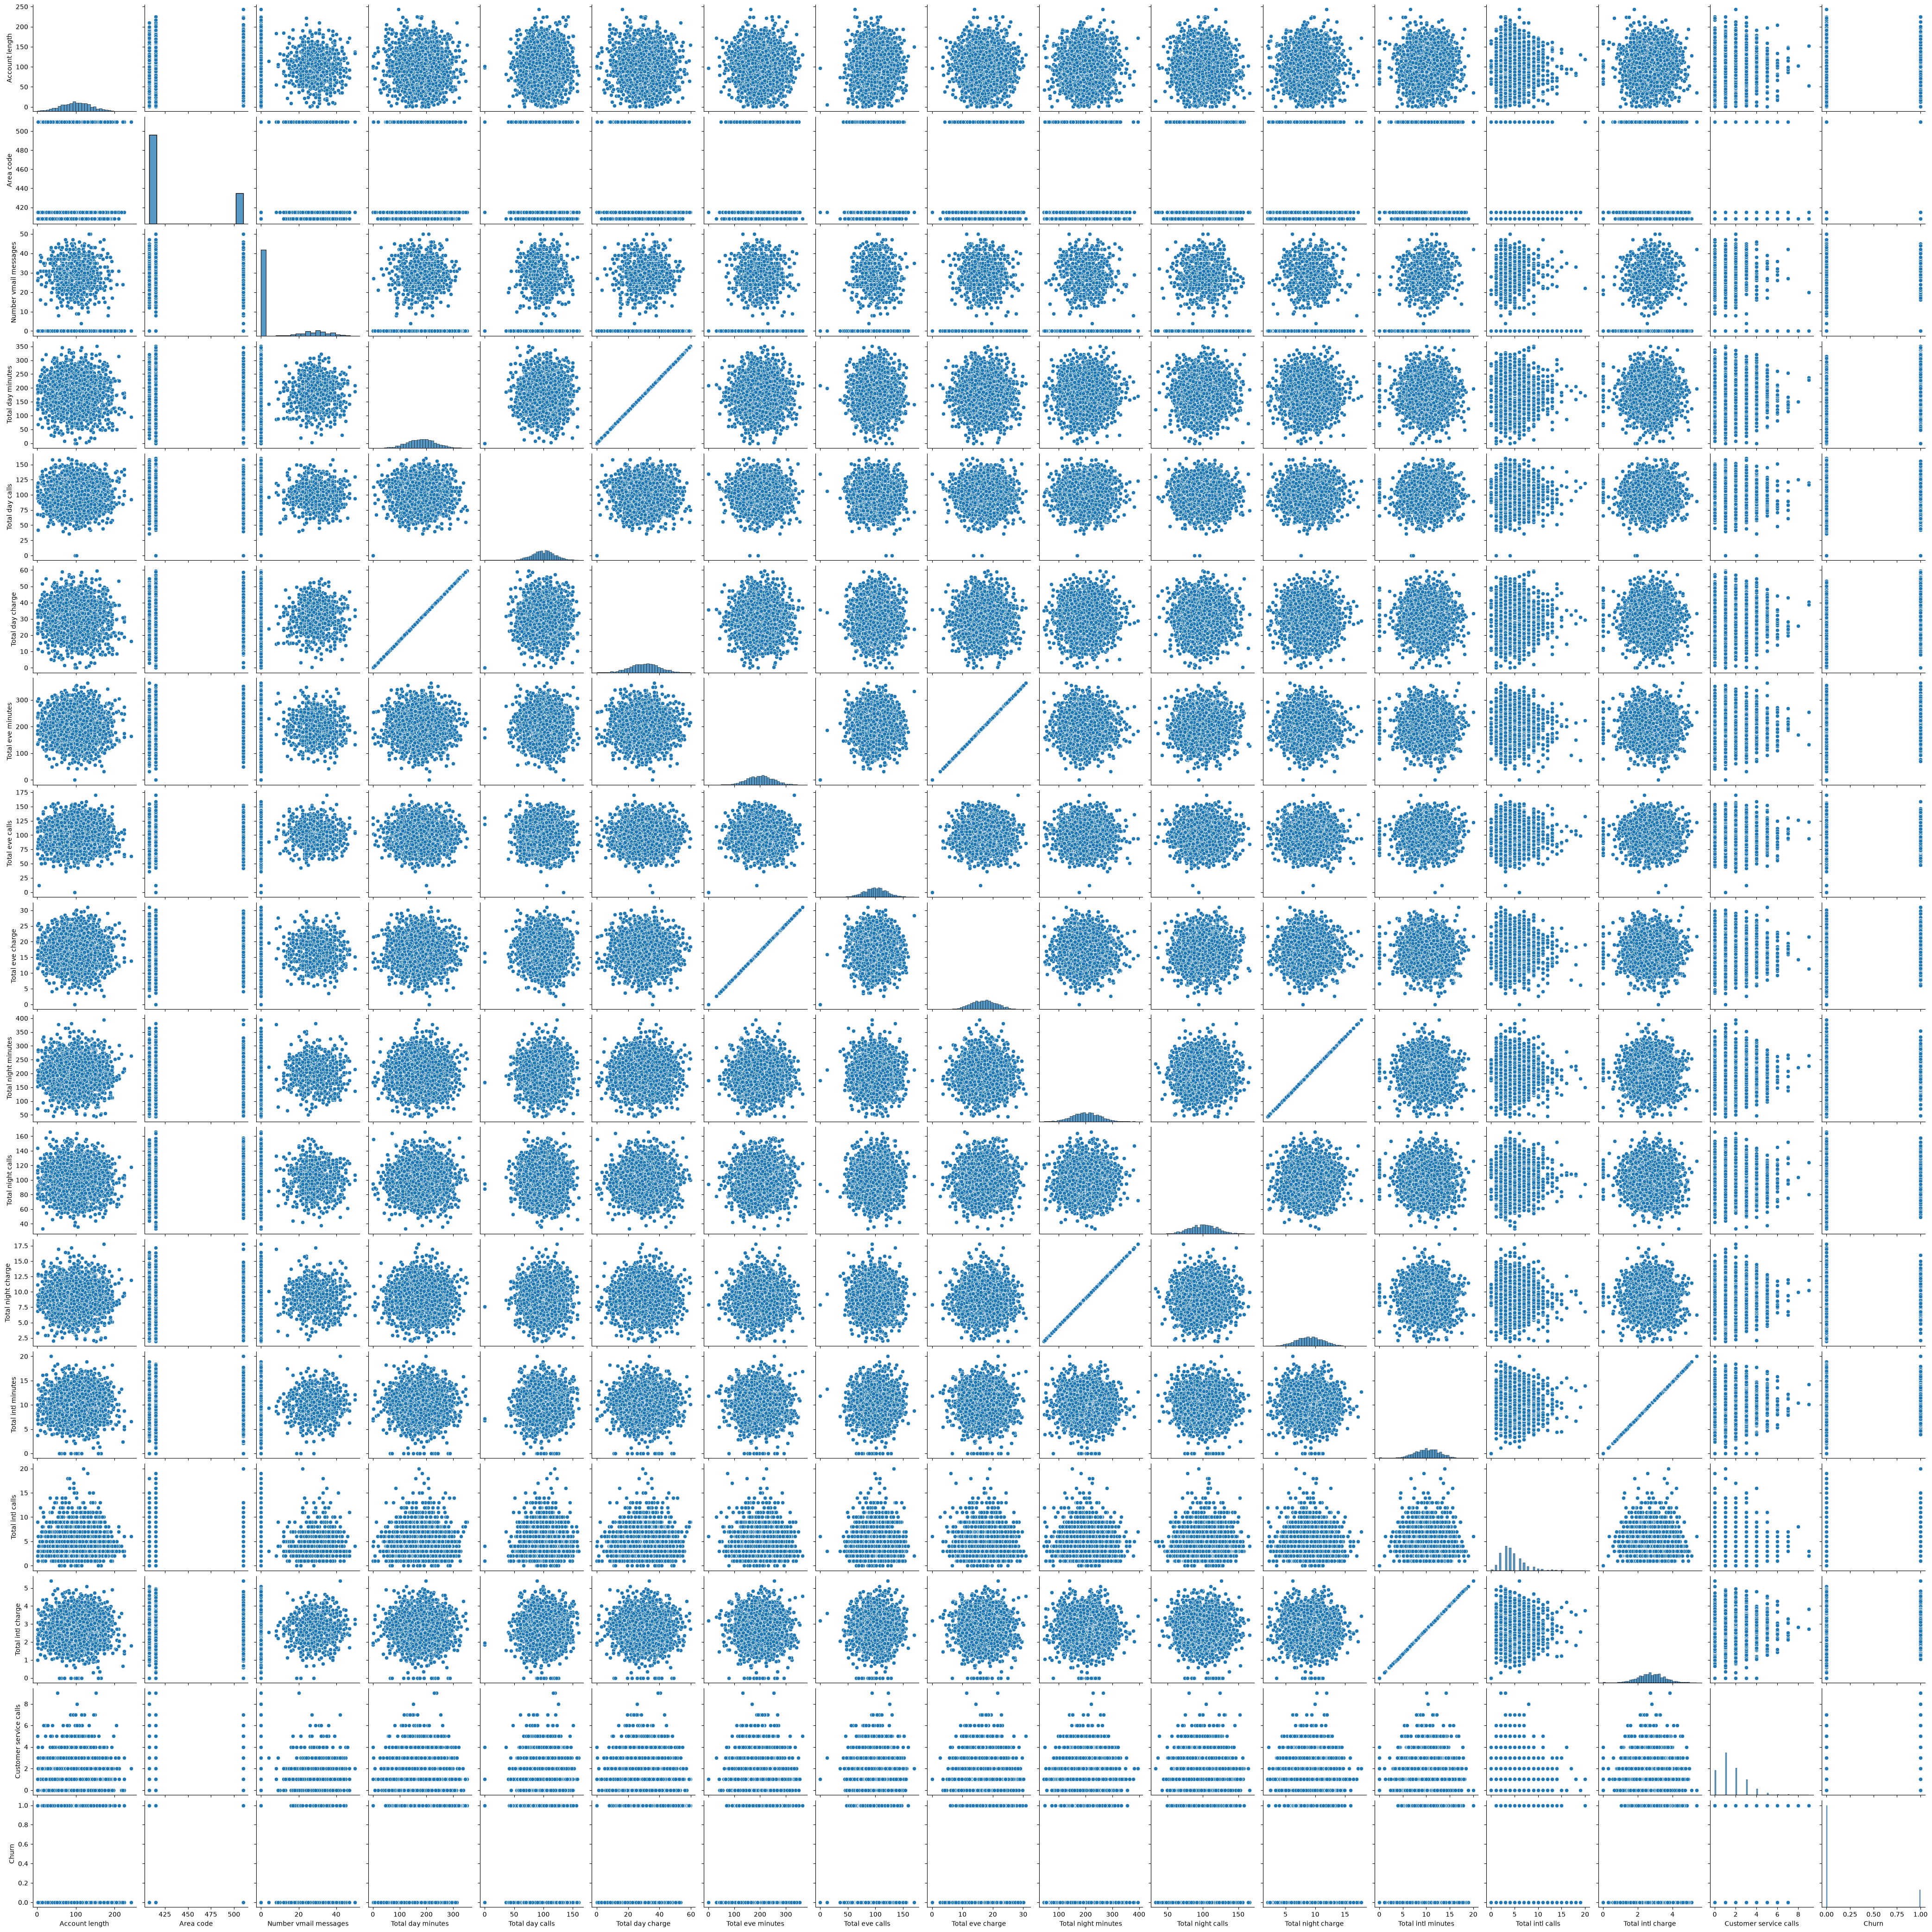

In [16]:
# pair plot
sns.pairplot(df_train)
plt.show()

## 4. Target Distribution


Before training the models, the distribution of the target variable is examined.

This is important because classification datasets can contain unequal numbers of observations for each class.

In [17]:
df_train["Churn"].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

In [18]:
df_train["Churn"].value_counts(normalize=True) * 100

Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64

## 5. Plot Churn Distribution

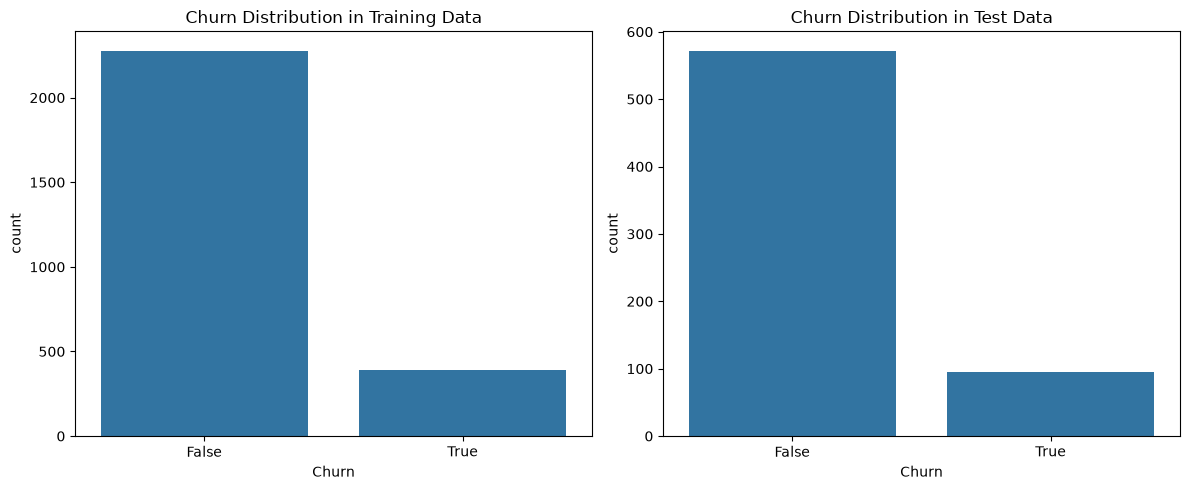

In [19]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=df_train)
plt.title('Churn Distribution in Training Data')

plt.subplot(1, 2, 2)
sns.countplot(x='Churn', data=df_test)
plt.title('Churn Distribution in Test Data')

plt.tight_layout()
plt.show()


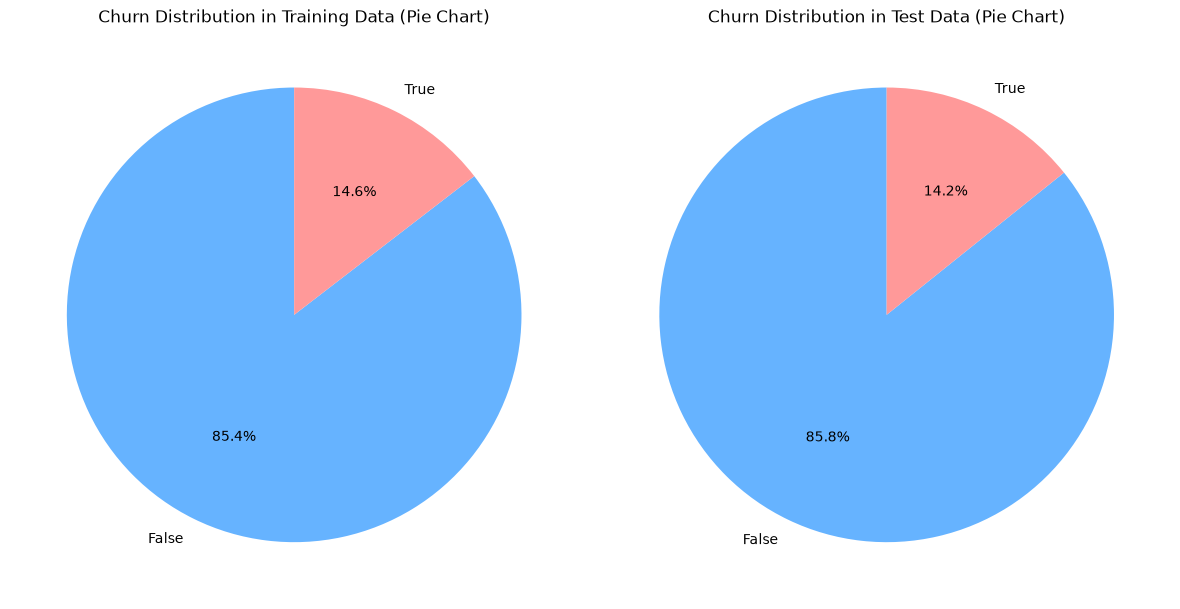

In [20]:
plt.figure(figsize=(12, 6))

# Pie chart for Training Data
plt.subplot(1, 2, 1)
train_churn_counts = df_train['Churn'].value_counts()
plt.pie(train_churn_counts, labels=train_churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Churn Distribution in Training Data (Pie Chart)')

# Pie chart for Test Data
plt.subplot(1, 2, 2)
test_churn_counts = df_test['Churn'].value_counts()
plt.pie(test_churn_counts, labels=test_churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Churn Distribution in Test Data (Pie Chart)')

plt.tight_layout()
plt.show()

## 6. Explain the dataset class imbalance

### Observation

The dataset contains more non-churn customers than churn customers.

Therefore, the target variable is imbalanced.

Because of this imbalance, model performance should not be evaluated using accuracy alone. Precision, recall, and F1-score are also important, especially for evaluating how well the model identifies customers who actually churn.

In [21]:
# Separate the feature and target
X_train = df_train.drop("Churn", axis=1)
y_train = df_train["Churn"]
X_test = df_test.drop("Churn", axis=1)
y_test = df_test["Churn"]


In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2666, 19)
(667, 19)
(2666,)
(667,)


## 7. Feature Preprocessing

The dataset contains both categorical and numerical variables.

Categorical features need to be converted into numerical representations before they can be used by machine-learning models.

Numerical features are standardized so that variables measured on different scales can be compared more effectively.

In [23]:
categorical_features = [
    "State",
    "Area code",
    "International plan",
    "Voice mail plan"
]

numerical_features = [
    column
    for column in X_train.columns
    if column not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['State', 'Area code', 'International plan', 'Voice mail plan']

Numerical features:
['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Explain about Preprocessing Strategy

Two preprocessing techniques are applied:

**StandardScaler**

StandardScaler transforms numerical variables to a comparable scale. This is particularly useful for algorithms such as Logistic Regression.

**OneHotEncoder**

OneHotEncoder converts categorical variables such as State, International Plan, and Voice Mail Plan into numerical indicator variables.

`handle_unknown="ignore"` ensures that an unseen category in the testing dataset does not cause an error.

## 8. Model Baseline model training
There are 3 models algorithm :

1.   Logistic Regression
2.   Decesion Tree
3.   Random Forest

Each model uses the same preprocessing pipeline to provide a fair comparison.



In [25]:
models = {
  "Logistic Regression": LogisticRegression(max_iter=100, random_state=RANDOM_STATE),
  "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
  "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)
}

In [26]:
results = []
trained_models = {}

for model_name, classifier in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", classifier)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[model_name] = pipeline

In [27]:
# Result Baseline model for three algorithm
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.940030,0.802198,0.768421,0.784946
1,Random Forest,0.943028,0.952381,0.631579,0.759494
2,Logistic Regression,0.856072,0.488889,0.231579,0.314286


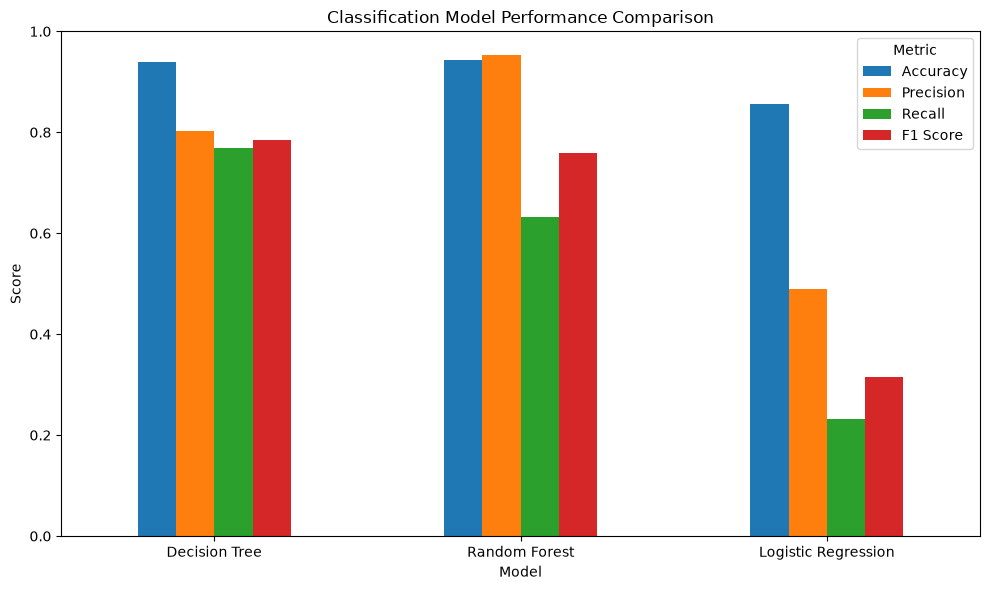

In [28]:
# Visulazation performance Model
metrics_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

metrics_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

In [29]:
best_model_name = results_df.iloc[0]["Model"]

print(
    "Best baseline model based on F1-score:",
    best_model_name
)

Best baseline model based on F1-score: Decision Tree


In [30]:
for model_name, pipeline in trained_models.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    y_pred = pipeline.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Churn", "Churn"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92       572
       Churn       0.49      0.23      0.31        95

    accuracy                           0.86       667
   macro avg       0.69      0.60      0.62       667
weighted avg       0.83      0.86      0.83       667

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.96      0.97      0.97       572
       Churn       0.80      0.77      0.78        95

    accuracy                           0.94       667
   macro avg       0.88      0.87      0.88       667
weighted avg       0.94      0.94      0.94       667

Random Forest
              precision    recall  f1-score   support

    No Churn       0.94      0.99      0.97       572
       Churn       0.95      0.63      0.76        95

    accuracy                           0.94       667
   macro avg       0.95      0.81      0.86       667
weighted avg       0.94   

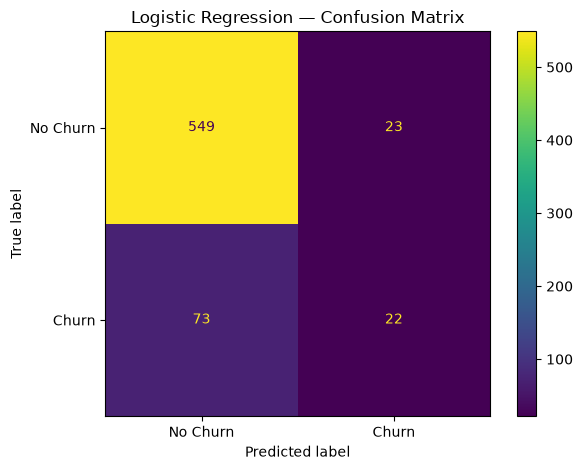

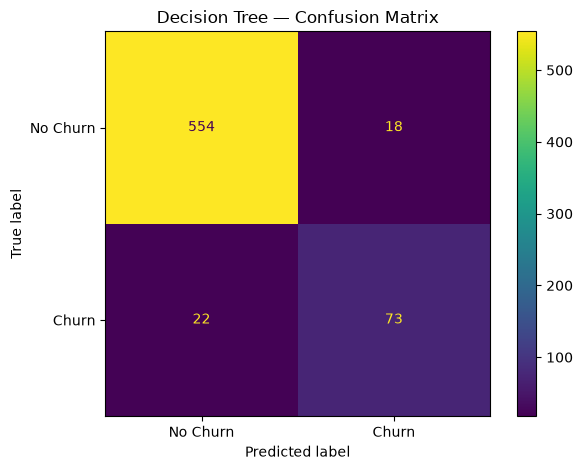

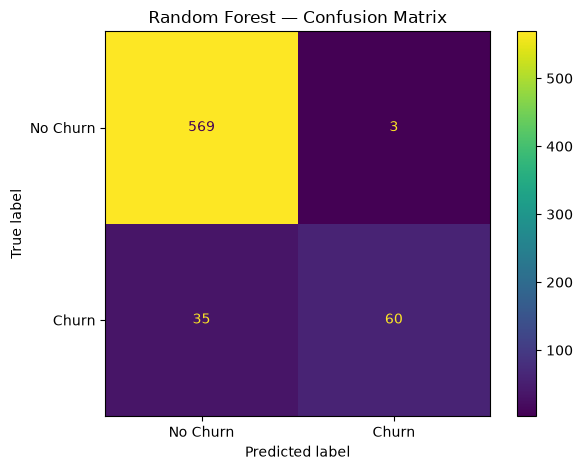

In [31]:
for model_name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Churn", "Churn"]
    )

    plt.title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

## 9.  Confusion Matrix Interpretation

The confusion matrix shows four possible prediction outcomes:

- **True Negative (TN):** Customer did not churn and the model correctly predicted no churn.
- **False Positive (FP):** Customer did not churn but the model predicted churn.
- **False Negative (FN):** Customer actually churned but the model predicted no churn.
- **True Positive (TP):** Customer churned and the model correctly predicted churn.

For a churn prediction system, false negatives are particularly important because they represent customers who are likely to leave but were not detected by the model.

## 10. Hyperparameter Tuning



### Hyperparameter Tuning with GridSearchCV

After comparing the baseline models, the model with the strongest F1-score is selected for hyperparameter tuning.

GridSearchCV systematically tests combinations of hyperparameter values using cross-validation.

F1-score is used as the scoring metric because the churn dataset contains an imbalanced target distribution.

In [32]:
# automatically select parameter for the best model
if best_model_name == "Logistic Regression":

    tuning_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    param_grid = {
        "model__C": [0.1, 1, 10],
        "model__class_weight": [
            None,
            "balanced"
        ]
    }


elif best_model_name == "Decision Tree":

    tuning_model = DecisionTreeClassifier(
        random_state=42
    )

    param_grid = {
        "model__max_depth": [
            None,
            5,
            10,
            15
        ],
        "model__min_samples_split": [
            2,
            5,
            10
        ],
        "model__class_weight": [
            None,
            "balanced"
        ]
    }


else:

    tuning_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    param_grid = {
        "model__n_estimators": [
            100,
            200
        ],
        "model__max_depth": [
            None,
            10,
            20
        ],
        "model__min_samples_split": [
            2,
            5
        ],
        "model__class_weight": [
            None,
            "balanced"
        ]
    }

In [33]:
# create the pipeline for the best model
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tuning_model)
    ]
)

In [34]:
grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    verbose=1,
    n_jobs=-1
)
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_

In [35]:
print("Model tuned:", best_model_name)

print("\nBest parameters:")
print(grid_search.best_params_)

print(
    "\nBest cross-validation F1-score:",
    round(grid_search.best_score_, 4)
)

Model tuned: Decision Tree

Best parameters:
{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_split': 10}

Best cross-validation F1-score: 0.7407


In [36]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)


In [37]:
# Tuning classification Model
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.97      0.98      0.97       572
       Churn       0.84      0.80      0.82        95

    accuracy                           0.95       667
   macro avg       0.91      0.89      0.90       667
weighted avg       0.95      0.95      0.95       667



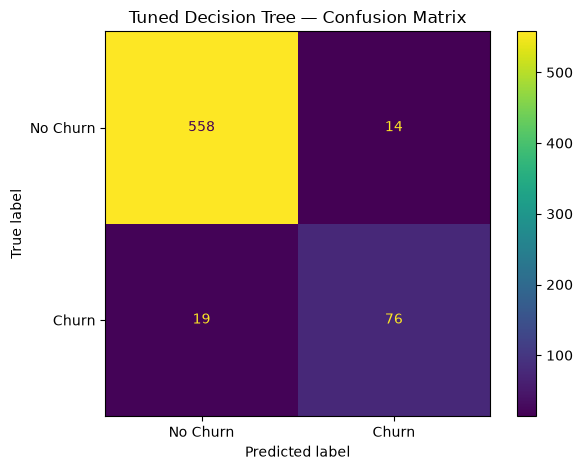

In [38]:
# Tuning confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

plt.title(
    f"Tuned {best_model_name} — Confusion Matrix"
)

plt.tight_layout()
plt.show()


## 11.  Compare before tuning and after tuning model


In [39]:
baseline_row = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, zero_division=0)
tuned_recall = recall_score(y_test, y_pred_tuned, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred_tuned, zero_division=0)

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Before Tuning": [
        baseline_row["Accuracy"],
        baseline_row["Precision"],
        baseline_row["Recall"],
        baseline_row["F1 Score"]
    ],

    "After Tuning": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.940030,0.950525
1,Precision,0.802198,0.844444
2,Recall,0.768421,0.800000
3,F1 Score,0.784946,0.821622


## 12. Plot before and after

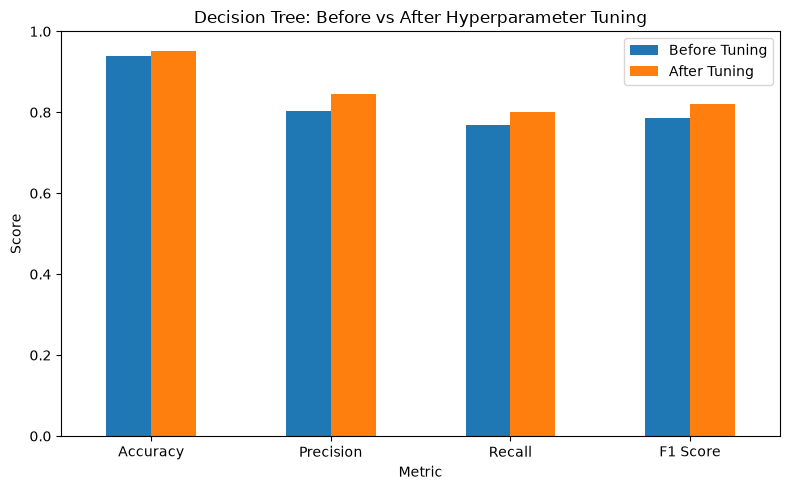

In [40]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    f"{best_model_name}: Before vs After Hyperparameter Tuning"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Key Findings

1. The customer churn dataset contains both numerical and categorical variables, requiring feature scaling and categorical encoding before model training.

2. The target variable is imbalanced, with substantially more customers remaining with the company than leaving.

3. Logistic Regression, Decision Tree, and Random Forest classifiers were trained and evaluated.

4. The models were compared using Accuracy, Precision, Recall, and F1-score rather than relying only on accuracy.

5. The model with the strongest baseline F1-score was **Decision Tree**.

6. Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation.

7. After tuning, the final model achieved:
   - Accuracy: **0.9505**
   - Precision: **0.8444**
   - Recall: **0.8000**
   - F1-score: **0.8216**

8. The confusion matrix was used to examine correct churn predictions as well as false-positive and false-negative predictions.

# Task 2: Building Dashboards with Power BI/Tableau
Description: Create interactive dashboards using a
data visualization tool like Power BI or Tableau to
present insights from a dataset.
### Objectives:
Import and clean the dataset in Power BI/Tableau.
Create interactive visualizations (e.g., bar charts, line
graphs, maps).
Set up filters and slicers for interactive exploration.
Publish the dashboard and share it with others.
### Tools: Power BI or Tableau.


## 1. Load data sentiment

In [41]:
df = pd.read_csv("cleaned_sentiment_dataset.csv")
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,Jan,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,Jan,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,Jan,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,Jan,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,Jan,15,19


## 2. check Data Quanlity

In [42]:
df.shape

(710, 13)

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Text       710 non-null    str  
 1   Sentiment  710 non-null    str  
 2   Timestamp  710 non-null    str  
 3   User       710 non-null    str  
 4   Platform   710 non-null    str  
 5   Hashtags   710 non-null    str  
 6   Retweets   710 non-null    int64
 7   Likes      710 non-null    int64
 8   Country    710 non-null    str  
 9   Year       710 non-null    int64
 10  Month      710 non-null    str  
 11  Day        710 non-null    int64
 12  Hour       710 non-null    int64
dtypes: int64(5), str(8)
memory usage: 189.9 KB


In [45]:
df.isna().sum()

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

In [46]:
df.isnull().sum()

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

## 3. Convert text to numberical and date time

In [47]:
text_columns = [
    "Text",
    "Sentiment",
    "User",
    "Platform",
    "Hashtags",
    "Country"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("Final text cleaning completed.")

Final text cleaning completed.


In [48]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

print("Invalid timestamps:", df["Timestamp"].isna().sum())
print("Earliest timestamp:", df["Timestamp"].min())
print("Latest timestamp:", df["Timestamp"].max())


Invalid timestamps: 0
Earliest timestamp: 2010-05-15 15:30:00
Latest timestamp: 2023-10-22 20:45:00


In [49]:
country_mapping = {
    "USA": "United States",
    "UK": "United Kingdom",
    "Scotland": "United Kingdom"
}

df["Country"] = df["Country"].replace(country_mapping)

print("Unique countries:", df["Country"].nunique())
display(df["Country"].value_counts().head(15))


Unique countries: 32


Country
United States     184
United Kingdom    141
Canada            131
Australia          70
India              68
Brazil             17
France             16
Japan              15
Germany            14
Italy              11
South Africa        6
Greece              5
Spain               5
Netherlands         4
Sweden              2
Name: count, dtype: int64

In [50]:
platform_mapping = {
    "instagram": "Instagram",
    "twitter": "Twitter",
    "facebook": "Facebook"
}

df["Platform"] = (
    df["Platform"]
    .str.strip()
    .str.lower()
    .replace(platform_mapping)
)

display(df["Platform"].value_counts())


Platform
Instagram    251
Twitter      236
Facebook     223
Name: count, dtype: int64

# 4. Transform the month as text to number for example like jan ==> 1

In [51]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.strftime("%b")
df["Month_Number"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Hour"] = df["Timestamp"].dt.hour

month_check = (
    df[["Month", "Month_Number"]]
    .drop_duplicates()
    .sort_values("Month_Number")
    .reset_index(drop=True)
)

display(month_check)


,Month,Month_Number
0,Jan,1
1,Feb,2
2,Mar,3
3,Apr,4
4,May,5
5,Jun,6
6,Jul,7
7,Aug,8
8,Sep,9
9,Oct,10


In [52]:
df["Likes"] = pd.to_numeric(df["Likes"], errors="coerce").astype("Int64")
df["Retweets"] = pd.to_numeric(df["Retweets"], errors="coerce").astype("Int64")

print(df[["Likes", "Retweets"]].dtypes)


Likes       Int64
Retweets    Int64
dtype: object


In [53]:
print("Number of unique sentiment/emotion labels:", df["Sentiment"].nunique())

top_10_sentiments = df["Sentiment"].value_counts().head(10)
display(top_10_sentiments)


Number of unique sentiment/emotion labels: 191


Sentiment
Positive       45
Joy            44
Excitement     37
Neutral        18
Contentment    18
Gratitude      17
Curiosity      16
Serenity       15
Happy          14
Despair        11
Name: count, dtype: int64

In [54]:
print("Missing values by column:")
display(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values by column:


Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
Month_Number    0
dtype: int64


Total missing values: 0
Duplicate rows: 0


In [55]:
print("=" * 60)
print("FINAL POWER BI DATA CHECK")
print("=" * 60)

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

print("\nDate range:")
print(df["Timestamp"].min(), "to", df["Timestamp"].max())

print("\nPlatforms:")
print(df["Platform"].value_counts())

print("\nNumber of countries:", df["Country"].nunique())
print("Number of sentiment/emotion labels:", df["Sentiment"].nunique())

print("\nLikes range:")
print(df["Likes"].min(), "to", df["Likes"].max())

print("\nRetweets range:")
print(df["Retweets"].min(), "to", df["Retweets"].max())

print("\nInvalid timestamp rows:", df["Timestamp"].isna().sum())
print("Duplicate rows:", df.duplicated().sum())


FINAL POWER BI DATA CHECK
Rows: 710
Columns: 14

Date range:
2010-05-15 15:30:00 to 2023-10-22 20:45:00

Platforms:
Platform
Instagram    251
Twitter      236
Facebook     223
Name: count, dtype: int64

Number of countries: 32
Number of sentiment/emotion labels: 191

Likes range:
10 to 80

Retweets range:
5 to 40

Invalid timestamp rows: 0
Duplicate rows: 0


In [56]:
display(df.head())
print("\nFinal columns:")
print(df.columns.tolist())


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Month_Number
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,United States,2023,Jan,15,12,1
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,Jan,15,8,1
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,United States,2023,Jan,15,15,1
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,United Kingdom,2023,Jan,15,18,1
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,Jan,15,19,1



Final columns:
['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour', 'Month_Number']


In [57]:
output_file = "powerbi_ready_sentiment_dataset.csv"

df.to_csv(
    output_file,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

print("Saved:", output_file)


Saved: powerbi_ready_sentiment_dataset.csv


In [58]:
check_df = pd.read_csv("powerbi_ready_sentiment_dataset.csv")

print("Exported dataset shape:", check_df.shape)
print("\nColumns:")
print(check_df.columns.tolist())

display(check_df.head())


Exported dataset shape: (710, 14)

Columns:
['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour', 'Month_Number']


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Month_Number
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,United States,2023,Jan,15,12,1
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,Jan,15,8,1
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,United States,2023,Jan,15,15,1
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,United Kingdom,2023,Jan,15,18,1
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,Jan,15,19,1


# Conclusion

The cleaned sentiment dataset has been prepared for Power BI.

The preparation included:

- final text standardization,
- datetime conversion,
- country-name standardization,
- platform standardization,
- date-component validation,
- creation of `Month_Number`,
- numeric validation for Likes and Retweets,
- preservation of the original detailed sentiment/emotion labels,
- missing-value and duplicate checks,
- final export to `powerbi_ready_sentiment_dataset.csv`.

### Power BI setup after import

In Power BI:

1. Set `Timestamp` to **Date/Time**.
2. Set `Country` data category to **Country/Region**.
3. Set `Likes`, `Retweets`, and `Month_Number` to **Whole Number**.
4. Select `Month` → **Column tools** → **Sort by column** → `Month_Number`.
5. Use a **Top N = 10** filter for the detailed `Sentiment` chart if needed.

The dataset is now ready for the interactive dashboard.


# Task 3: Natural Language Processing (NLP) - Sentiment Analysis
Description: Perform sentiment analysis on textual
data (e.g., customer reviews, social media comments)
to classify text as positive, negative, or neutral.

### Objectives:

Preprocess text data (tokenization, removing
stopwords, and stemming/lemmatization).
Use nltk or TextBlob for sentiment analysis.
Visualize the sentiment distribution and word
frequencies using word clouds.
Tools: Python, nltk, TextBlob, pandas, matplotlib.


In [59]:
import pandas as pd
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

import matplotlib.pyplot as plt

from wordcloud import WordCloud
from collections import Counter

ModuleNotFoundError: No module named 'nltk'

## 1. Load data

In [ ]:
df_nlp = pd.read_csv("cleaned_sentiment_dataset.csv")
df_nlp.head()

## 2. Initial Data Inspection

In [ ]:
df_nlp.shape

In [ ]:
df_nlp.info()

In [ ]:
df_nlp.isna().sum()

In [ ]:
df_nlp.duplicated().sum()

In [ ]:
df_nlp.columns.tolist()

In [ ]:
# convert data type 'Timestamp' from objetive to timedate
df_nlp['Timestamp'] = pd.to_datetime(df_nlp['Timestamp'])
df_nlp.info()

In [ ]:
df.describe(include="all")

In [ ]:
df_nlp = df_nlp.dropna(subset=["Text"]).copy() # Remove missing Text rows

In [ ]:
df_nlp["Text"] = df_nlp["Text"].astype(str) # Convert text to string

In [ ]:
# Original comments
for i, text in enumerate(df["Text"].head(10), start=1):
    print(f"{i}. {text}")

## 3. Prepare stopword and lemmatier

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

## 4. Create text preprocessing function

In [ ]:
def preprocess_text(text):
    text = text.lower()     # Convert to lowercase
    text = re.sub(r"http\S+|www\S+", "", text)    # Remove URLs
    text = re.sub(r"@\w+", "", text) # Remove @mentions
    text = text.replace("#", "")
    text = re.sub(r"\d+", "", text) # Remove numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)     # Remove punctuation and special characters
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces

    tokens = word_tokenize(text)    # Tokenization

    # Remove stopwords and short tokens
    tokens = [
        word
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join tokens back into text
    cleaned_text = " ".join(tokens)

    return cleaned_text

## 5. Test Preprocessing on one sentence

In [ ]:
example = "I really loved the restaurants and the services were amazing!"

print("Original:")
print(example)

print("\nCleaned:")
print(preprocess_text(example))

##

## 6. Apply preprocessing to all comments

In [ ]:
df_nlp["clean_text"] = df_nlp["Text"].apply(preprocess_text)

# Original comments
for i, text in enumerate(df_nlp["Text"].head(10), start=1):
    print(f"{i}. {text}")

## 7. Check for empty clean comment

In [ ]:
empty_cleaned = (df_nlp["clean_text"].str.strip() == "").sum()

print("Empty cleaned comments:", empty_cleaned)

## 8. Create TextBox Polarity function

In Natural Language Processing (NLP), polarity measures whether a piece of text expresses a positive, negative, or neutral emotional orientation or sentiment

In [ ]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

## 9. Calculate sentiment Polarity

In [ ]:
df_nlp["Polarity"] = df_nlp["Text"].apply(get_polarity)

In [ ]:
df_nlp[["Text", "Polarity"]].head(10)

## 10.  Create sentiment classification function

In [ ]:
def classify_sentiment(polarity):
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

## 11. Generate predict sentiment

In [ ]:
df_nlp["Predicted_Sentiment"] = df_nlp["Polarity"].apply(classify_sentiment)

In [ ]:
df_nlp[
    [
        "Text",
        "clean_text",
        "Polarity",
        "Predicted_Sentiment"
    ]
].head(20)

## 12. Check sentiment count

In [ ]:
sentiment_counts = df_nlp["Predicted_Sentiment"].value_counts()
sentiment_counts

## 13. Calculate percentage

In [ ]:
sentiment_percentages = (
    df_nlp["Predicted_Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_percentages

In [ ]:
sentiment_summary = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage": sentiment_percentages
})

sentiment_summary

## 14. Visualize sentiment distribution

In [ ]:
order = ["Positive", "Neutral", "Negative"]

sentiment_counts_ordered = (
    df_nlp["Predicted_Sentiment"]
    .value_counts()
    .reindex(order, fill_value=0)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    sentiment_counts_ordered.index,
    sentiment_counts_ordered.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Save distribution of sentiment
plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_counts_ordered.index,
    sentiment_counts_ordered.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.tight_layout()

plt.savefig(
    "sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Prepare all the clean text
all_words = " ".join(df_nlp["clean_text"].dropna()).split()

print("Total cleaned words:", len(all_words))

In [ ]:
# Final the most frequent
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)

top_words

In [ ]:
# Convert top 15 into DataFrame
top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

top_words_df

In [ ]:
# Plot 15 frequency word
plt.figure(figsize=(10, 6))

plt.barh(
    top_words_df["Word"],
    top_words_df["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 15 Most Frequent Words")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Save top word
plt.figure(figsize=(10, 6))

plt.barh(
    top_words_df["Word"],
    top_words_df["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 15 Most Frequent Words")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "top_15_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Create overall word cloud

In [ ]:
all_text = " ".join(
    df_nlp["clean_text"].dropna()
)

In [ ]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(all_text)

plt.figure(figsize=(14, 7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Overall Word Cloud")

plt.show()

In [ ]:
# Save overall world cloud
wordcloud.to_file("overall_wordcloud.png")

## 16. Create positive world cloud

In [ ]:
positive_text = " ".join(
    df_nlp.loc[
        df_nlp["Predicted_Sentiment"] == "Positive",
        "clean_text"
    ].dropna()
)

In [ ]:
positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(positive_text)

plt.figure(figsize=(14, 7))

plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Positive Sentiment Word Cloud")

plt.show()

In [ ]:
positive_wordcloud.to_file(
    "positive_wordcloud.png"
)

## 17. Create negative world cloud

In [ ]:
negative_text = " ".join(
    df_nlp.loc[
        df_nlp["Predicted_Sentiment"] == "Negative",
        "clean_text"
    ].dropna()
)

In [ ]:
negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(negative_text)

plt.figure(figsize=(14, 7))

plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Negative Sentiment Word Cloud")

plt.show()

In [ ]:
negative_wordcloud.to_file(
    "negative_wordcloud.png"
)

## 18. Netrual world cloud

In [ ]:
neutral_text = " ".join(
    df_nlp.loc[
        df_nlp["Predicted_Sentiment"] == "Neutral",
        "clean_text"
    ].dropna()
)

In [ ]:
if neutral_text.strip():

    neutral_wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=150
    ).generate(neutral_text)

    plt.figure(figsize=(14, 7))

    plt.imshow(
        neutral_wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")
    plt.title("Neutral Sentiment Word Cloud")

    plt.show()

## 19. Analyze sentiment by platform

In [ ]:
sentiment_platform = pd.crosstab(
    df_nlp["Platform"],
    df_nlp["Predicted_Sentiment"]
)

sentiment_platform

## 20. Visualize sentiment by platform

In [ ]:
sentiment_platform = sentiment_platform.reindex(
    columns=["Positive", "Neutral", "Negative"],
    fill_value=0
)

sentiment_platform.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Comments")

plt.xticks(rotation=0)

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

## 21. Analyze Avarage like by sentiment

In [ ]:
# Calculate average likes for each predicted sentiment
avg_likes_sentiment = (
    df.groupby("Predicted_Sentiment")["Likes"]
      .mean()
      .reindex(["Positive", "Neutral", "Negative"])
)

print("Average Likes by Predicted Sentiment:")
print(avg_likes_sentiment)

# Plot
plt.figure(figsize=(8, 5))

bars = plt.bar(
    avg_likes_sentiment.index,
    avg_likes_sentiment.values
)

# Add values above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Likes by Predicted Sentiment")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Average Likes")

plt.tight_layout()
plt.show()

## 22. Analyze Avarage Retween by sentiment

In [ ]:
avg_retweets_sentiment = (
    df_nlp.groupby("Predicted_Sentiment")["Retweets"]
    .mean()
    .reindex(["Positive", "Neutral", "Negative"])
)

avg_retweets_sentiment

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_retweets_sentiment.index,
    avg_retweets_sentiment.values
)

plt.title("Average Retweets by Predicted Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Retweets")

plt.tight_layout()
plt.show()

## 23. Check highest positive comments

In [ ]:
df_nlp.nlargest(
    10,
    "Polarity"
)[
    [
        "Text",
        "Platform",
        "Polarity",
        "Predicted_Sentiment"
    ]
]

## 24. Check most negative comments

In [ ]:
df_nlp.nsmallest(
    10,
    "Polarity"
)[
    [
        "Text",
        "Platform",
        "Polarity",
        "Predicted_Sentiment"
    ]
]

## 25. Check most Neurual comments

In [ ]:
df_nlp[
    df_nlp["Predicted_Sentiment"] == "Neutral"
][
    [
        "Text",
        "Polarity",
        "Predicted_Sentiment"
    ]
].head(20)

## 26. Create final Anlysis table

In [ ]:
final_columns = [
    "Text",
    "clean_text",
    "Polarity",
    "Predicted_Sentiment",
    "Platform",
    "Country",
    "Likes",
    "Retweets"
]

sentiment_results = df_nlp[final_columns].copy()

sentiment_results.head()

## 27. Export final CSV

In [ ]:
sentiment_results.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

## 28. Verify saved file

In [ ]:
saved_df = pd.read_csv(
    "sentiment_analysis_results.csv"
)

print(saved_df.shape)

saved_df.head()

## 29. Generate a final summary automatically

In [ ]:
total_comments = len(df)

positive_count = (
    df["Predicted_Sentiment"] == "Positive"
).sum()

neutral_count = (
    df["Predicted_Sentiment"] == "Neutral"
).sum()

negative_count = (
    df["Predicted_Sentiment"] == "Negative"
).sum()

print("NLP Sentiment Analysis Summary")
print("-" * 40)

print(f"Total comments: {total_comments}")

print(
    f"Positive: {positive_count} "
    f"({positive_count / total_comments * 100:.2f}%)"
)

print(
    f"Neutral: {neutral_count} "
    f"({neutral_count / total_comments * 100:.2f}%)"
)

print(
    f"Negative: {negative_count} "
    f"({negative_count / total_comments * 100:.2f}%)"
)

In [ ]:
# Prepare data
sentiment_labels = ["Positive", "Neutral", "Negative"]
sentiment_values = [
    positive_count,
    neutral_count,
    negative_count
]

def autopct_with_count(values):
    def format_pct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return format_pct

plt.figure(figsize=(8, 6))

plt.pie(
    sentiment_values,
    labels=sentiment_labels,
    autopct=autopct_with_count(sentiment_values),
    startangle=90
)

plt.title("Predicted Sentiment Distribution")

plt.axis("equal")
plt.tight_layout()
plt.show()